<a href="https://colab.research.google.com/github/hrulevskaya/ML_tasks/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.__version__)

import tensorflow.keras as  keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape,AveragePooling2D, SeparableConv2D,Conv2D, MaxPooling2D
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

2.20.0


In [ ]:
dir = '/content/gdrive/MyDrive/dataset'
categories = os.listdir(dir)





/tmp/ipykernel_1943/1166831690.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(i)


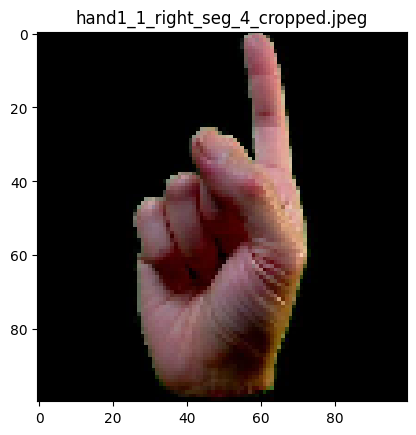

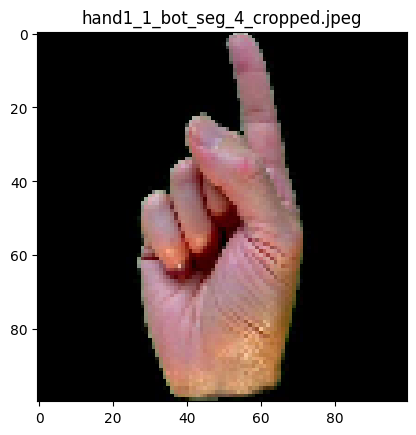

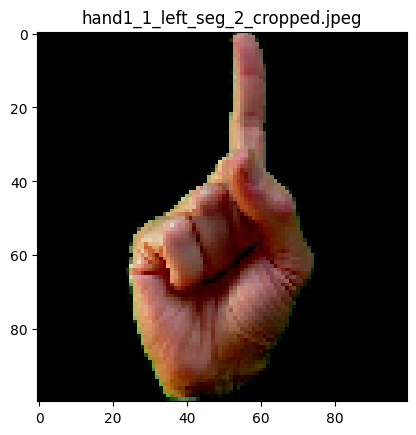

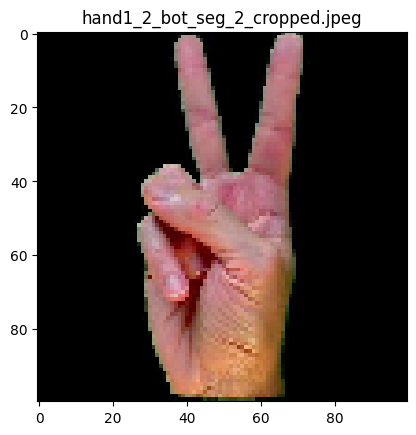

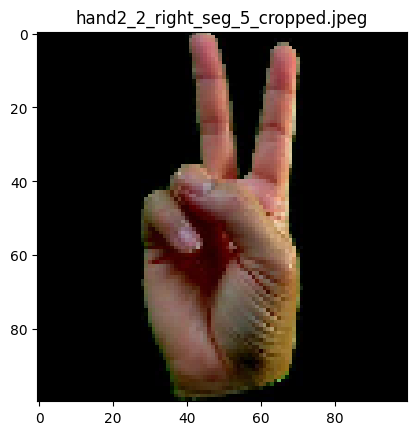

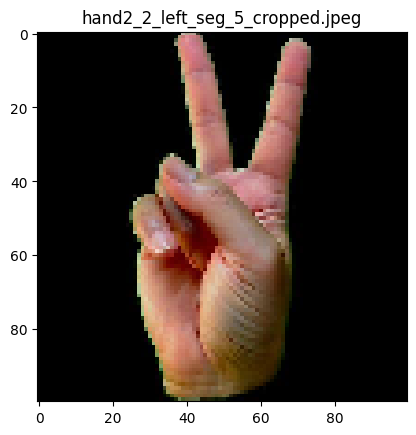

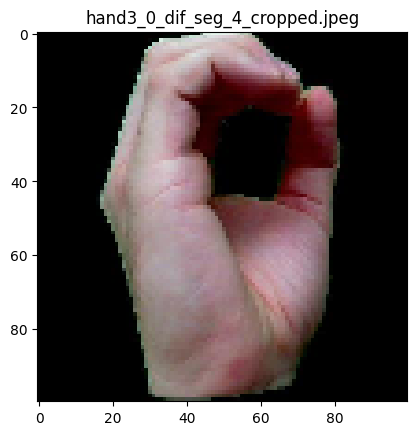

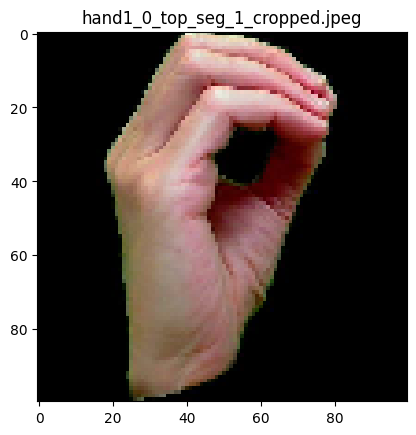

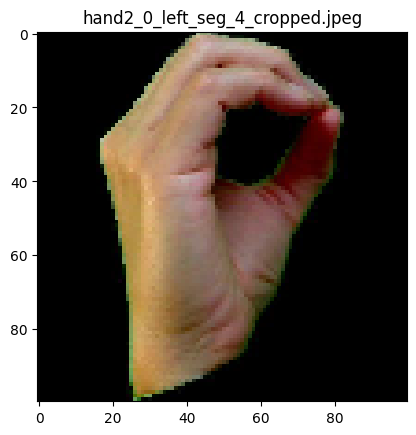

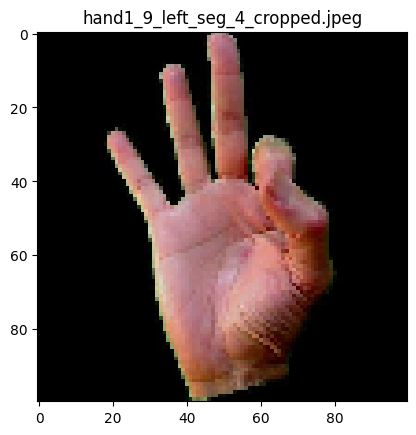

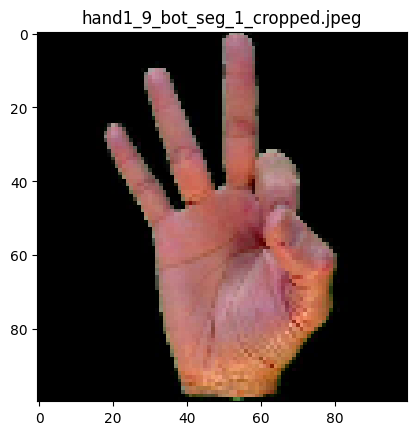

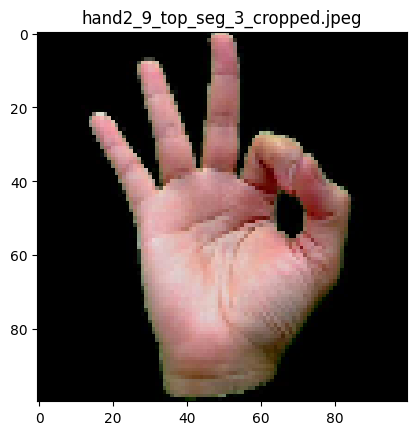

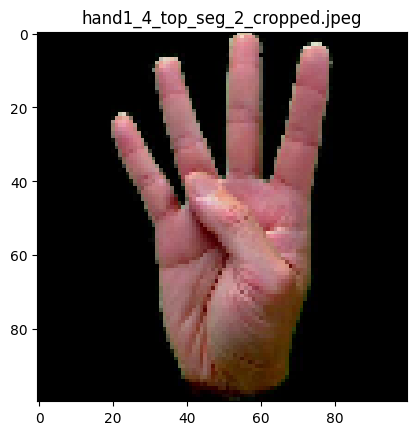

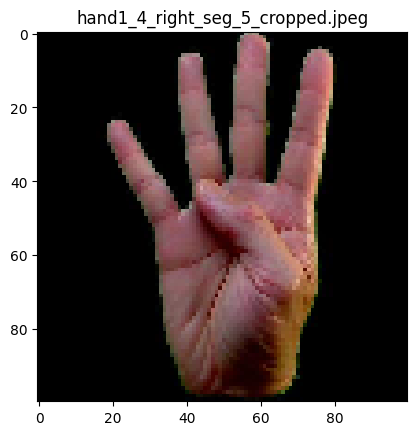

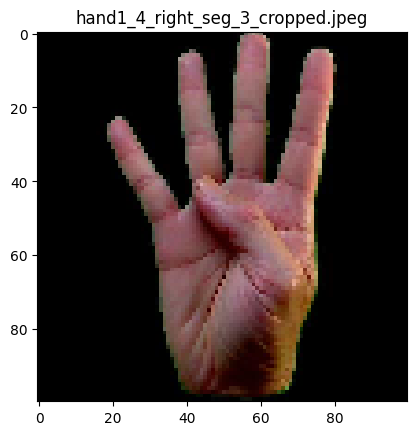

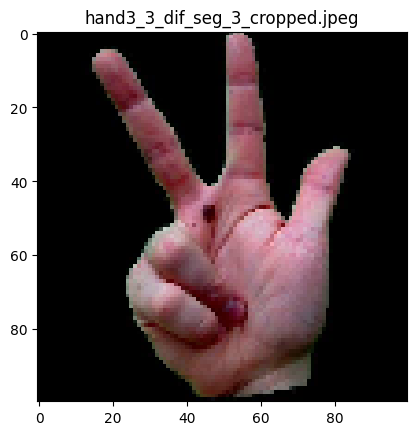

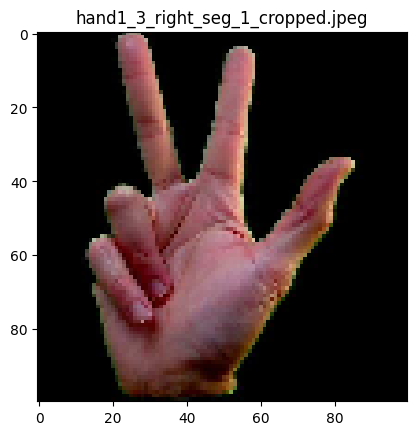

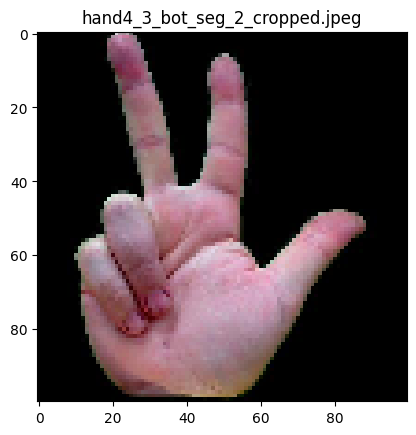

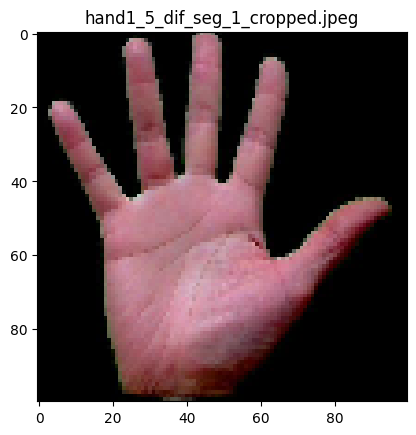

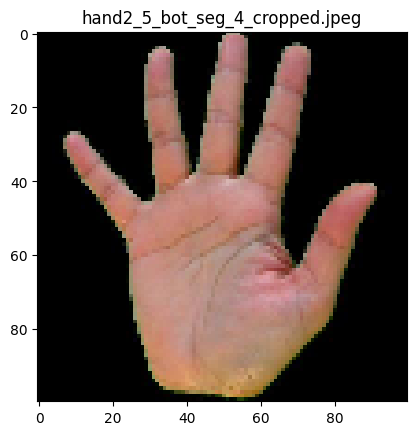

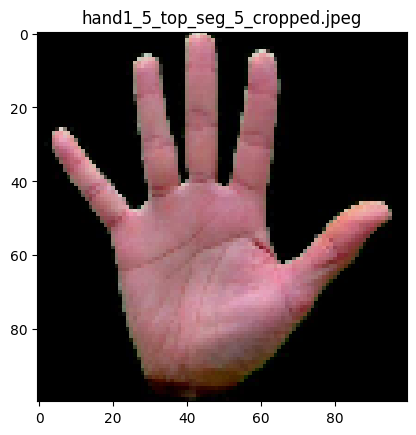

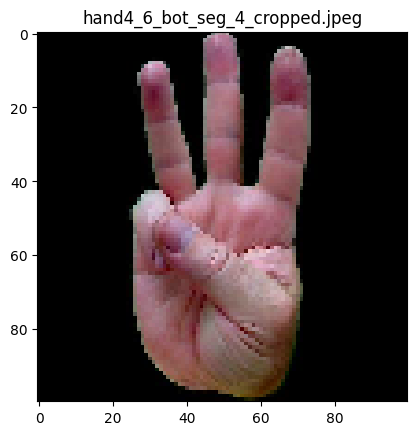

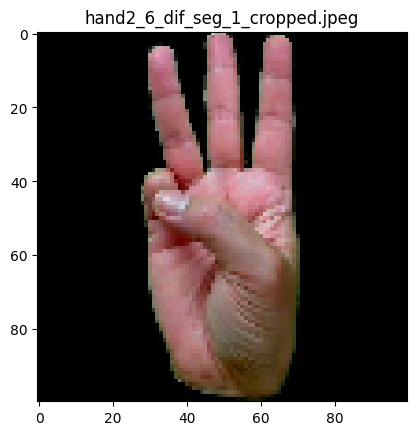

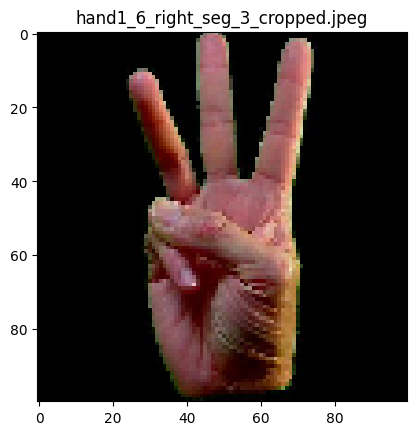

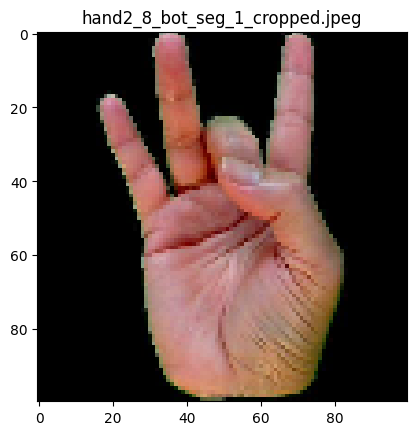

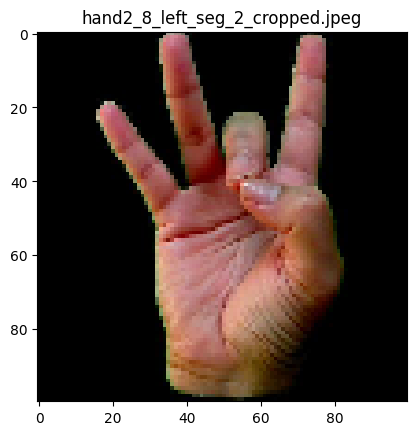

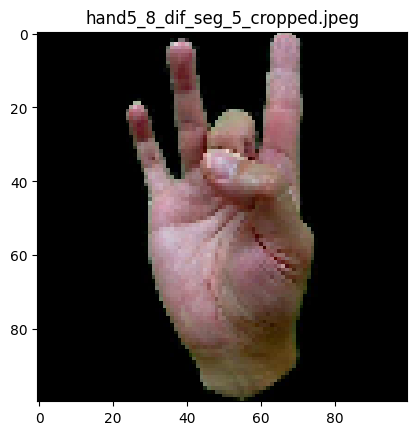

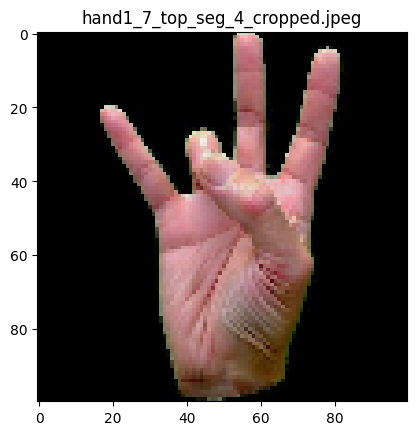

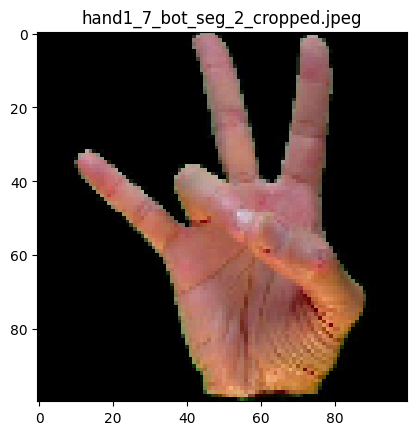

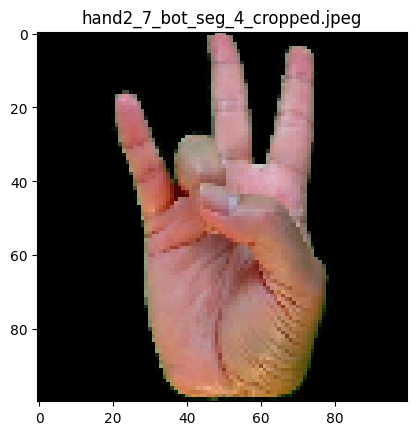

In [ ]:
fnames = []

for category in categories:
    if category.isdigit():
        category_dir = os.path.join(dir, category)
        fnames.extend([os.path.join(category_dir, fname) for fname in os.listdir(category_dir)][:3])

i = 0
for img_path in fnames:
    img = image.load_img(img_path, target_size=(100, 100))
    plt.figure(i)
    plt.grid(False)
    imgplot = plt.imshow(img)
    plt.title(os.path.basename(img_path))
    i += 1

plt.show()

In [ ]:
from tensorflow.keras.applications import mobilenet,mobilenet_v2
categories = os.listdir(dir)
INPUT_SHAPE = 224
net_model = mobilenet_v2
net_model_class = net_model.MobileNetV2
c = 0
model = net_model_class(weights='imagenet', input_shape=(INPUT_SHAPE, INPUT_SHAPE, 3), include_top=False, pooling='avg')
features_dict = {}

for category in categories:
  if category.isdigit():
    category_dir = os.path.join(dir, category)
    category_fnames = [os.path.join(category_dir, fname) for fname in os.listdir(category_dir)][:]

    for img_path in category_fnames:
        c += 1
        img = image.load_img(img_path, target_size=(INPUT_SHAPE, INPUT_SHAPE))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = net_model.preprocess_input(x)

        preds = model.predict(x, verbose=0)
        features_dict[img_path] = preds

print(c)

700


In [ ]:
X1 = []
Y = []
for key, value in features_dict.items():
    folder_name = os.path.basename(os.path.dirname(key))
    label = int(folder_name)

    X1.append(value.flatten())
    Y.append(label)

In [ ]:
data_X = np.array(X1)
data_Y = np.array(Y)

In [ ]:
print("Shape of X:", data_X.shape)
print("Shape of Y:", data_Y.shape)
print("Распределение классов:", np.bincount(data_Y))

Shape of X: (700, 1280)
Shape of Y: (700,)
Распределение классов: [70 70 70 70 70 70 70 70 70 70]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

X_train, X_test, Y_train, Y_test = train_test_split(data_X, data_Y, test_size=0.2, random_state=2, stratify=data_Y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def calc_metrics_cls(true, pred):
    stats = {
        'Accuracy': round(metrics.accuracy_score(true, pred),4),
        'F1': round(metrics.f1_score(true, pred, average='macro'),4)
    }
    print(f"Accuracy: {stats['Accuracy']}\nF1: {stats['F1']}")
    return stats
cls_models_stats = {}

In [ ]:
from sklearn.ensemble import RandomForestClassifier

cls_model_rf = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
cls_model_rf.fit(X_train, Y_train)
Y_pred_cls_rf = cls_model_rf.predict(X_test)

cls_models_stats['RandomForest'] = calc_metrics_cls(Y_test, Y_pred_cls_rf)

Accuracy: 0.9857
F1: 0.9857


In [ ]:
from sklearn.linear_model import SGDClassifier

cls_model_sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)
cls_model_sgd.fit(X_train, Y_train)
Y_pred_cls_sgd = cls_model_sgd.predict(X_test)
cls_models_stats['SGDClassifier'] = calc_metrics_cls(Y_test, Y_pred_cls_sgd)

Accuracy: 0.9857
F1: 0.9857


In [ ]:
from sklearn.svm import SVC

cls_model_svc = SVC(C=10, gamma='scale', random_state=42)
cls_model_svc.fit(X_train, Y_train)
Y_pred_cls_svc = cls_model_svc.predict(X_test)

cls_models_stats['SVC'] = calc_metrics_cls(Y_test, Y_pred_cls_svc)

Accuracy: 0.9857
F1: 0.9859


In [ ]:
model_cls_compare = pd.DataFrame(cls_models_stats).T
model_cls_compare

,Accuracy,F1
RandomForest,0.9857,0.9857
SGDClassifier,0.9857,0.9857
SVC,0.9857,0.9859
